In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score
from sklearn.decomposition import PCA

from imblearn.over_sampling import SMOTE

# Latihan 1

In [2]:
latsol1 = pd.read_csv('../data/latsol1.csv')

print("Data lengkap CSV:")
display(latsol1)

data = latsol1[['Temperatur Udara', 'Kecepatan Angin', 'Klasifikasi atau Persepsi Marry']]
data = data.dropna()

print("\nData Training yang tidak digunakan:")
display(data)

Data lengkap CSV:


,Temperatur Udara,Kecepatan Angin,Klasifikasi atau Persepsi Marry
0,10,0,Dingin
1,25,0,Panas
2,15,5,Dingin
3,20,3,Panas
4,18,7,Dingin
5,20,10,Dingin
6,22,5,Panas
7,24,6,Panas



Data Training yang tidak digunakan:


,Temperatur Udara,Kecepatan Angin,Klasifikasi atau Persepsi Marry
0,10,0,Dingin
1,25,0,Panas
2,15,5,Dingin
3,20,3,Panas
4,18,7,Dingin
5,20,10,Dingin
6,22,5,Panas
7,24,6,Panas


In [3]:
X = data[['Temperatur Udara', 'Kecepatan Angin']]
y = data['Klasifikasi atau Persepsi Marry']

# Bagi data 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Cari K terbaik (1–5)
best_k = 1
best_acc = 0
for k in range(1, 6):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"K={k}, Akurasi={acc}")
    if acc > best_acc:
        best_acc = acc
        best_k = k

print(f"\nK terbaik: {best_k}, Akurasi: {best_acc}")

# Prediksi data uji (16, 3)
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X, y)
hasil = knn_best.predict([[16, 3]])

print("\nPrediksi untuk data (Suhu=16°C, Angin=3 km/jam):", hasil[0])

K=1, Akurasi=1.0
K=2, Akurasi=1.0
K=3, Akurasi=0.5
K=4, Akurasi=0.5
K=5, Akurasi=0.5

K terbaik: 1, Akurasi: 1.0

Prediksi untuk data (Suhu=16°C, Angin=3 km/jam): Dingin


d:\Code\college-task\machine-learning-task\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


# Latihan 2

In [4]:
latsol2 = pd.read_csv('../data/latsol2.csv')
display(latsol2)

y_true = latsol2['Hasil Sebenarnya']
y_pred = latsol2['Hasil Prediksi']

cm = confusion_matrix(y_true, y_pred, labels=["Lulus", "Tidak Lulus"])
cm_df = pd.DataFrame(cm,
                     index=["Actual Lulus", "Actual Tidak Lulus"],
                     columns=["Pred Lulus", "Pred Tidak Lulus"])

print("\n Confusion Matrix:")
display(cm_df)

# Hitung evaluasi
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, pos_label="Lulus")
recall = recall_score(y_true, y_pred, pos_label="Lulus")

print(f"Accuracy  : {accuracy:.2%}")
print(f"Precision : {precision:.2%}")
print(f"Recall    : {recall:.2%}")

,Nim,Hasil Sebenarnya,Hasil Prediksi
0,TI001,Lulus,Lulus
1,TI002,Lulus,Lulus
2,TI003,Lulus,Lulus
3,TI004,Lulus,Tidak Lulus
4,TI005,Lulus,Tidak Lulus
5,TI006,Tidak Lulus,Lulus
6,TI007,Tidak Lulus,Tidak Lulus
7,TI008,Tidak Lulus,Tidak Lulus
8,TI009,Tidak Lulus,Tidak Lulus
9,TI010,Tidak Lulus,Tidak Lulus



 Confusion Matrix:


,Pred Lulus,Pred Tidak Lulus
Actual Lulus,3,2
Actual Tidak Lulus,1,4


Accuracy  : 70.00%
Precision : 75.00%
Recall    : 60.00%


# Praktikum Mandiri

In [5]:
# Load dataset
df = pd.read_csv('../data/weather_classification_data.csv')
print('Shape:', df.shape)
df.head()


Shape: (13200, 11)


,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [6]:
# Info dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


In [7]:
# Cek missing values
print('Missing values per column:')
print(df.isnull().sum())
print('\nUnique values Weather Type:')
print(df['Weather Type'].value_counts())


Missing values per column:
Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64

Unique values Weather Type:
Weather Type
Rainy     3300
Cloudy    3300
Sunny     3300
Snowy     3300
Name: count, dtype: int64


In [8]:
# Encoding categorical variables
from sklearn.preprocessing import LabelEncoder

le_season = LabelEncoder()
le_location = LabelEncoder()
le_cloud = LabelEncoder()
le_weather = LabelEncoder()

df['Season_enc'] = le_season.fit_transform(df['Season'])
df['Location_enc'] = le_location.fit_transform(df['Location'])
df['Cloud Cover_enc'] = le_cloud.fit_transform(df['Cloud Cover'])
df['Weather Type_enc'] = le_weather.fit_transform(df['Weather Type'])

print('Season mapping:', dict(zip(le_season.classes_, le_season.transform(le_season.classes_))))
print('Location mapping:', dict(zip(le_location.classes_, le_location.transform(le_location.classes_))))
print('Cloud Cover mapping:', dict(zip(le_cloud.classes_, le_cloud.transform(le_cloud.classes_))))
print('Weather Type mapping:', dict(zip(le_weather.classes_, le_weather.transform(le_weather.classes_))))


Season mapping: {'Autumn': np.int64(0), 'Spring': np.int64(1), 'Summer': np.int64(2), 'Winter': np.int64(3)}
Location mapping: {'coastal': np.int64(0), 'inland': np.int64(1), 'mountain': np.int64(2)}
Cloud Cover mapping: {'clear': np.int64(0), 'cloudy': np.int64(1), 'overcast': np.int64(2), 'partly cloudy': np.int64(3)}
Weather Type mapping: {'Cloudy': np.int64(0), 'Rainy': np.int64(1), 'Snowy': np.int64(2), 'Sunny': np.int64(3)}


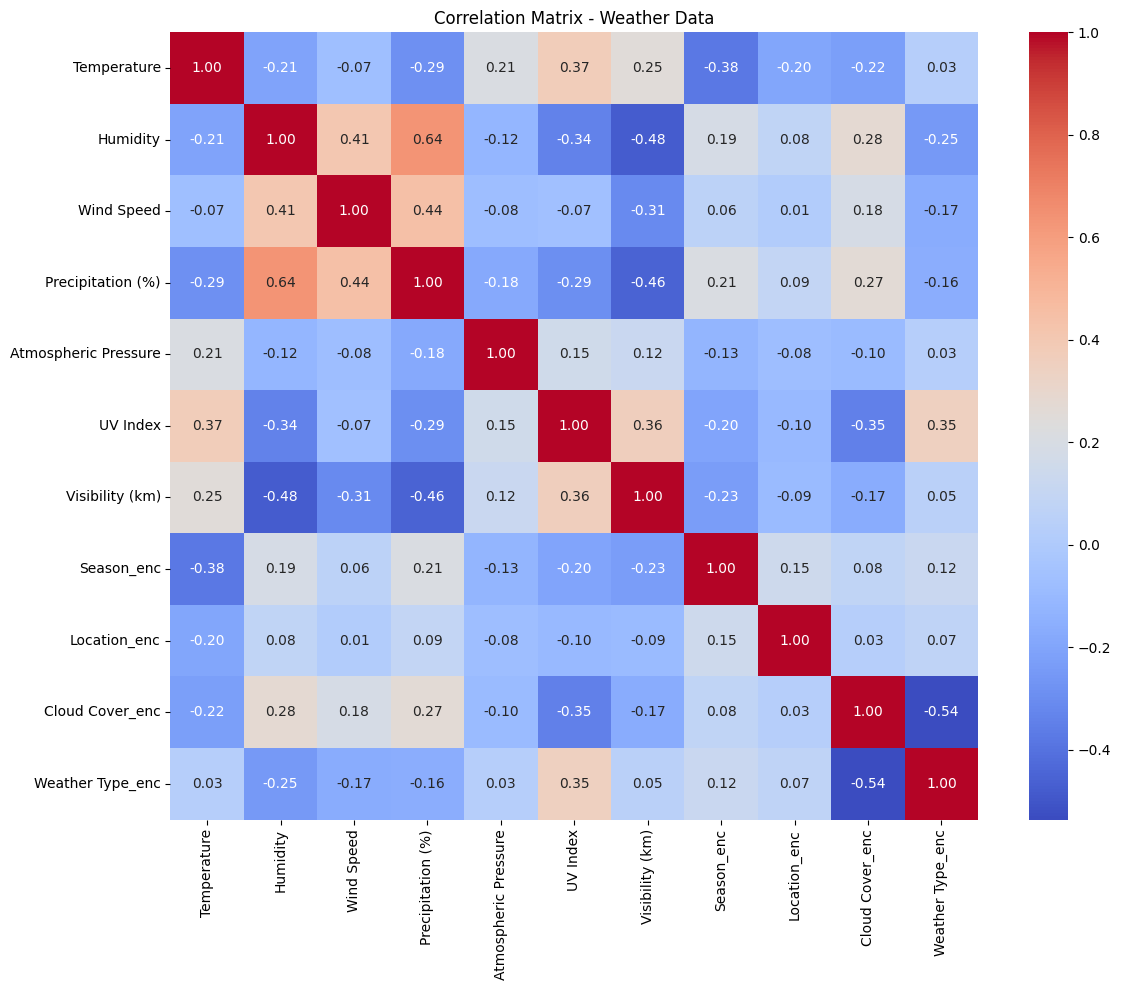

In [9]:
# Correlation heatmap
numeric_cols = ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 
                'Atmospheric Pressure', 'UV Index', 'Visibility (km)',
                'Season_enc', 'Location_enc', 'Cloud Cover_enc', 'Weather Type_enc']

correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title('Correlation Matrix - Weather Data')
plt.tight_layout()
plt.show()


C:\Users\tiant\AppData\Local\Temp\ipykernel_11644\284677315.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Weather Type', data=df, palette='Set2', order=df['Weather Type'].value_counts().index)


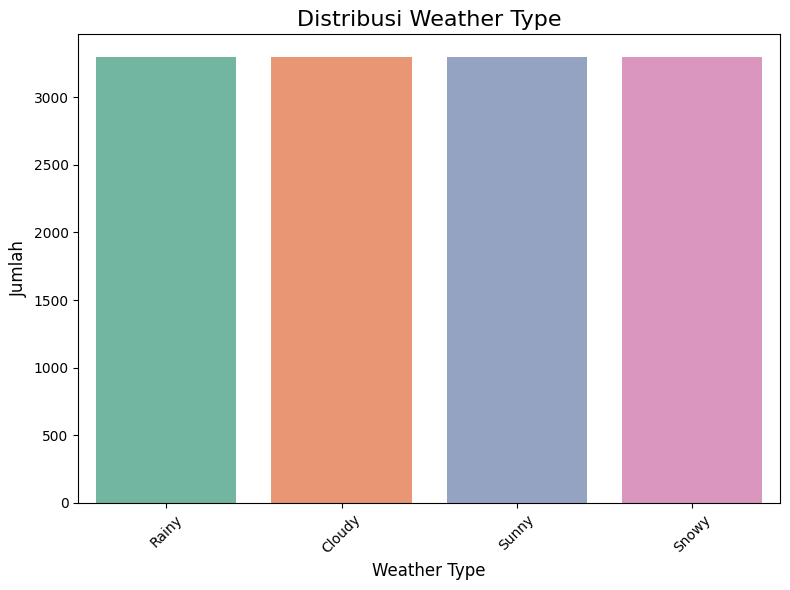

In [10]:
# Distribusi Weather Type
plt.figure(figsize=(8, 6))
sns.countplot(x='Weather Type', data=df, palette='Set2', order=df['Weather Type'].value_counts().index)
plt.title('Distribusi Weather Type', fontsize=16)
plt.xlabel('Weather Type', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [11]:
# Prepare features & target (split train-test)
X = df[['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 
        'Atmospheric Pressure', 'UV Index', 'Visibility (km)',
        'Season_enc', 'Location_enc', 'Cloud Cover_enc']]
y = df['Weather Type_enc']

# Split data 80% train, 20% test dengan stratify untuk menjaga proporsi kelas
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train distribution:\n', y_train.value_counts().sort_index())


X_train shape: (10560, 10)
X_test shape: (2640, 10)
y_train distribution:
 Weather Type_enc
0    2640
1    2640
2    2640
3    2640
Name: count, dtype: int64


In [12]:
# Scaling features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Scaled X_train (first 5 rows):')
print(X_train_scaled[:5])


Scaled X_train (first 5 rows):
[[-1.50484353  0.07142947 -1.21527274  0.57485863 -0.43837101 -0.77813687
  -1.024227    0.98478749  1.14908808  0.00749271]
 [-1.21634579 -0.42429555  0.52440058  0.66861308 -0.21029017 -0.77813687
  -0.2857228   0.98478749  1.14908808  0.00749271]
 [-1.04324715  1.31074201 -0.8528408   1.35614574 -0.48366556 -1.0374258
  -0.72882532  0.98478749 -0.1141193   0.00749271]
 [ 0.05304424 -0.47386805  0.01699586 -1.17522451  0.25364395  1.55546347
   1.1912856   0.12845054  1.14908808  0.9965301 ]
 [ 0.57234017 -1.8123256  -0.99781358 -1.20647599  0.17323942  1.8147524
   0.15737972 -0.7278864  -1.37732669 -1.97058208]]


In [13]:
# Check class imbalance (optional SMOTE)
print("Distribution y_train:")
print(y_train.value_counts())

# Jika imbalance signifikan, bisa pakai SMOTE (opsional)
# Untuk dataset weather ini distribusi cukup seimbang, skip SMOTE


Distribution y_train:
Weather Type_enc
2    2640
3    2640
1    2640
0    2640
Name: count, dtype: int64


In [14]:
# GridSearchCV untuk hyperparameter tuning
param_grid = {
    'n_neighbors': list(range(3, 21, 2)),  # 3, 5, 7, ..., 19
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(
    KNeighborsClassifier(), 
    param_grid, 
    cv=5, 
    n_jobs=-1,
    scoring='accuracy',
    verbose=1
)
grid.fit(X_train_scaled, y_train)

print("\nBest Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)


Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best Params: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}
Best CV Score: 0.9005681818181819

Best Params: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}
Best CV Score: 0.9005681818181819


In [15]:
# Train best model & predict
best_knn = grid.best_estimator_
best_knn.fit(X_train_scaled, y_train)

y_pred = best_knn.predict(X_test_scaled)

print('Model training completed.')
print('First 10 predictions:', y_pred[:10])


Model training completed.
First 10 predictions: [1 0 3 1 3 0 0 1 0 3]


In [16]:
# Evaluation: Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le_weather.classes_))



Classification Report:
              precision    recall  f1-score   support

      Cloudy       0.85      0.90      0.87       660
       Rainy       0.87      0.89      0.88       660
       Snowy       0.94      0.91      0.92       660
       Sunny       0.93      0.88      0.91       660

    accuracy                           0.90      2640
   macro avg       0.90      0.90      0.90      2640
weighted avg       0.90      0.90      0.90      2640



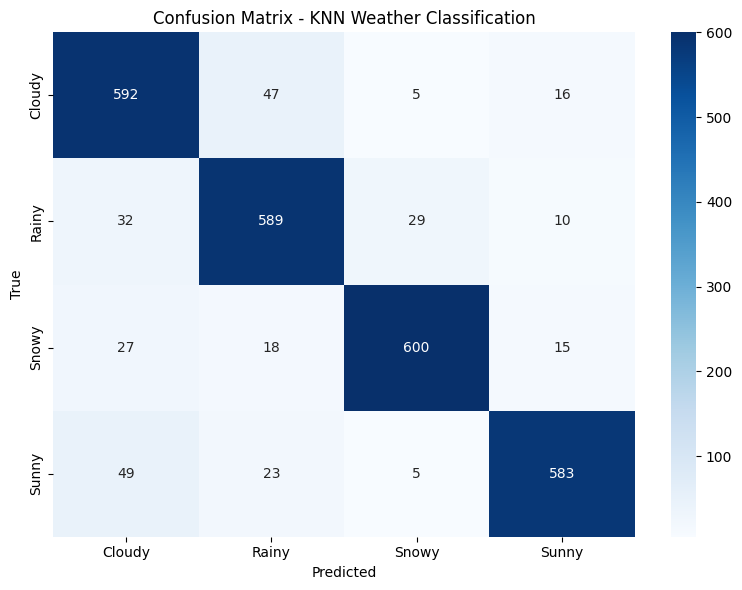

In [17]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_weather.classes_, 
            yticklabels=le_weather.classes_)
plt.title("Confusion Matrix - KNN Weather Classification")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


In [18]:
# Cross Validation Score
cv_scores = cross_val_score(best_knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
print("Cross Validation Accuracy (5-Fold):")
print("Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())
print("Std Dev:", cv_scores.std())


Cross Validation Accuracy (5-Fold):
Scores: [0.9000947  0.89867424 0.90530303 0.89867424 0.9000947 ]
Mean Accuracy: 0.9005681818181819
Std Dev: 0.0024511702851410413


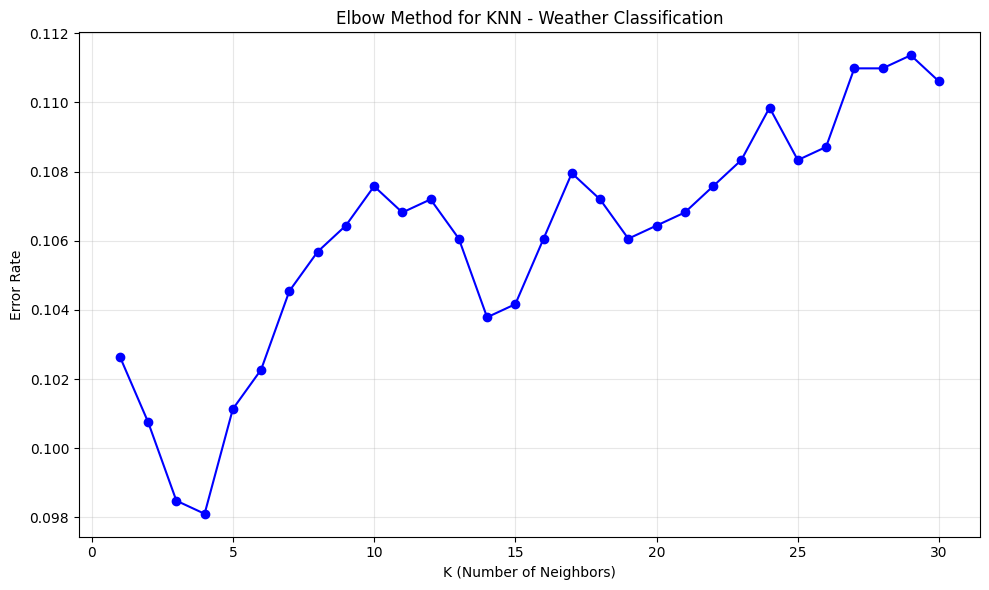

Minimum error rate: 0.0981 at K=4


In [19]:
# Elbow Method - Error Rate vs K
errors = []
k_range = range(1, 31)

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    pred = knn_temp.predict(X_test_scaled)
    errors.append(np.mean(pred != y_test))

plt.figure(figsize=(10, 6))
plt.plot(k_range, errors, marker='o', linestyle='-', color='b')
plt.title("Elbow Method for KNN - Weather Classification")
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Error Rate")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Minimum error rate: {min(errors):.4f} at K={k_range[errors.index(min(errors))]}")


In [20]:
# Prediksi contoh data baru (manual input)
# Contoh: Temperature=25, Humidity=60, Wind Speed=10, Precipitation=20, 
#         Pressure=1013, UV=5, Visibility=8, Season=Spring(2), Location=inland(1), Cloud=clear(0)

sample_data = [[25, 60, 10, 20, 1013, 5, 8, 2, 1, 0]]
sample_scaled = scaler.transform(sample_data)
prediction = best_knn.predict(sample_scaled)
predicted_weather = le_weather.inverse_transform(prediction)

print("Sample Input:")
print("Temperature=25, Humidity=60, Wind Speed=10, Precipitation=20%")
print("Pressure=1013, UV Index=5, Visibility=8km")
print("Season=Spring, Location=inland, Cloud Cover=clear")
print(f"\nPredicted Weather Type: {predicted_weather[0]}")


Sample Input:
Temperature=25, Humidity=60, Wind Speed=10, Precipitation=20%
Pressure=1013, UV Index=5, Visibility=8km
Season=Spring, Location=inland, Cloud Cover=clear

Predicted Weather Type: Sunny


d:\Code\college-task\machine-learning-task\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
